# Calibração do termo de tratamento Para a linhagem 92-1 (figura C)


Notebook complementar ao de crescimento. A ferramenta é a mesma; mudam apenas a
aplicação e os dados. No controle, comparavam-se sete *leis de crescimento*. Aqui,
o crescimento é **fixado** (com a lei e os parâmetros escolhidos a partir do
controle) e calibra-se o **termo de tratamento**.

Há várias formas possíveis para o termo de tratamento. Este notebook desenvolve
**em detalhe uma delas — o decaimento exponencial (ED)** — e, a partir dela,
mostra a **receita para construir as demais** (seção 7.1). A ideia é dominar o
padrão com um exemplo e depois replicá-lo para cada função da lista a testar.

## Ideia central

O modelo tem a forma

$$\frac{dT}{dt} = \underbrace{G(T)}_{\text{crescimento (fixo)}} \;-\; \underbrace{C(t,T)\,T}_{\text{efeito do tratamento}}$$

- $G(T)$: a lei de crescimento escolhida no controle, com parâmetros fixos
  (vindos da calibração do controle).
- $C(t,T)$: a taxa de eliminação induzida pelo tratamento, aplicada a partir do
  dia da terapia. As diferentes formas de $C$ são as *funções de teste* deste
  notebook.

## Etapas

1. Leitura dos dados do grupo tratado (mesma convenção de pastas/arquivos).
2. Definição do termo de crescimento fixo $G(T)$ (lei e parâmetros do controle).
3. Definição das funções de tratamento candidatas $C(t,T)$.
4. Calibração: para cada função de tratamento, estimam-se seus parâmetros e o
   volume inicial $T_0$ de cada camundongo.
5. Comparação das funções por BIC, AIC, AICc, RMSE e correlações.
6. Avaliação da predição do último ponto (validação *last-point*).
7. Geração de tabela, relatório, parâmetros e figura.

Os elementos de configuração estão reunidos na seção 2. A seção 5.1 contém uma
célula de exploração manual, útil para entender como cada função de tratamento
deforma a curva de crescimento antes da otimização automática.

## 1. Bibliotecas utilizadas

As mesmas do notebook de crescimento.

In [1]:
from pathlib import Path
import math
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import minimize
from tqdm import tqdm

## 2. Configuração

### (a) Dados
Mesma convenção do controle: uma pasta `data_figX` por grupo; dentro dela, um
`.csv` por camundongo (duas colunas: tempo e volume), no padrão
`..._fig3<PAINEL>_<GRUPO>_<número>.csv`. Para os dados tratados, altera-se apenas
`FILE_GLOB` para o rótulo correspondente (por exemplo, `..._NOG_CART_*.csv`).

### (b) Termo de crescimento (vindo do controle)
`GROWTH_MODEL` é a lei de crescimento escolhida no controle, e `GROWTH_PARAMS`
são os parâmetros estimados naquele ajuste (copiados do arquivo
`parameters_*.csv` gerado pelo notebook de crescimento). Esses valores ficam
**fixos**: descrevem o tumor sem tratamento. A justificativa é isolar o efeito do
tratamento, sem reabsorvê-lo em mudanças do crescimento.

Chaves esperadas em `GROWTH_PARAMS`, por lei:
`exponential`→`r`; `logistic`→`r,K`; `gompertz`→`r,K,c`; `mendelsohn`→`r,b`;
`bertalanffy`→`r,alpha`; `linear`/`surface`→`r,f`.

### (c) Esquema de tratamento
`TREATMENT_DAYS` lista os dias de aplicação e `DOSES` as doses correspondentes
(em unidades relativas; a escala absoluta é absorvida pelos parâmetros). Para uma
única aplicação no dia 0, usar `TREATMENT_DAYS=[0.0]` e `DOSES=[1.0]`. Para IL-2
em vários dias, por exemplo, `TREATMENT_DAYS=[0.0, 2.0, 4.0]` e `DOSES=[1.0,1.0,1.0]`.

### (d) Robustez e tempo de execução
Reduzir `MULTISTART_N_STARTS`, `OPT_MAXITER` e `VALIDATION_TOP_K` acelera a
execução; aumentá-los torna o ajuste mais criterioso.

In [2]:
# === (a) Dados (mesma convenção do controle) ===
DATA_ROOT    = None
FOLDER_REGEX = r"data_fig[C]+"
# Padrão dos arquivos de tratamento. Opções com os dados disponíveis:
#   CAR-T + IL-2 (painéis A, B, C, D): "data_frosberg19_fig3*_hIL2_NOG_CART_*.csv"
#   CAR-T sem IL-2 (apenas painel A):  "data_frosberg19_fig3A_NOG_CART_*.csv"
# O crescimento (GROWTH_PARAMS) deve vir do controle correspondente (ver seção 14).
FILE_GLOB = "data_frosberg19_fig3*_hIL2_NOG_CART_*.csv"
SORT_REGEX = r"fig3([C])_.*?_([0-9]+)\.csv$"

# === (b) Termo de crescimento fixo (vindo do controle) ===
GROWTH_MODEL  = "linear"               # lei escolhida no controle  Para a linhagem 92-1 (figura C)
GROWTH_PARAMS = {"r": 2.49815, "f": 14.2442}  # substituir pelos valores do controle
# === (c) Esquema de tratamento ===
TREATMENT_DAYS = [12.0]   # dia(s) de aplicação Para a linhagem 92-1 (figura C) dia 12

DOSES          = [1.0]   # dose(s) em unidades relativas

# === (d) Funções de tratamento a comparar ===
# Versão de ensino: linha de base (none) + decaimento exponencial (ED).
# Após estudar a receita da seção 7.1, acrescente aqui os nomes das demais
# funções implementadas, ex.: TREATMENT_MODELS = ["none", "ED", "CD", "MM"]
TREATMENT_MODELS = ["none", "ED", "CD", "AccelED", "MM", "LS", "dePR"]

# === (e) Robustez x velocidade ===
MULTISTART_N_STARTS = 6
OPT_MAXITER         = 250
VALIDATION_TOP_K    = 3
USE_LAST_POINT_VALIDATION = True

# === Quais grupos rodar ===
GROUPS_TO_RUN = None   # None = todos; ou ex.: ["data_figB"]

# === Opções gerais ===
COUNT_T0_IN_AIC_BIC = True
OUTPUT_DIRNAME = "calibration_outputs_tratamento"
RANDOM_SEED = 42
MODEL_SELECTION_METRIC = "BIC"
BOUNDARY_TOL_REL = 0.02
T0_BOUND_FRACTION_LOW  = 0.10
T0_BOUND_FRACTION_HIGH = 4.0
T0_BOUND_BUFFER = 0.0

## 3. Leitura e verificação dos dados

Funções idênticas às do notebook de crescimento — a leitura dos dados não muda.

In [3]:
def read_time_volume_file(filepath):
    '''Lê um arquivo de um camundongo e devolve DataFrame com colunas t, V.'''
    with open(filepath, "r", encoding="utf-8") as f:
        sample = "".join(f.readlines()[:10])
    sep = r"[;,]" if re.search(r"[;,]", sample) else r"\s+"
    df = pd.read_csv(
        filepath, header=None, names=["t", "V"], sep=sep, engine="python",
        comment="#", skip_blank_lines=True, skipinitialspace=True, usecols=[0, 1],
    )
    df["t"] = pd.to_numeric(df["t"], errors="coerce")
    df["V"] = pd.to_numeric(df["V"], errors="coerce")
    df = df.dropna(subset=["t", "V"]).copy()
    df = df.sort_values("t").reset_index(drop=True)
    return df


def validate_datasets(datasets, filepaths):
    '''Confere requisitos mínimos de cada camundongo.'''
    for i, (df, fp) in enumerate(zip(datasets, filepaths), start=1):
        t_obs = df["t"].to_numpy(float); v_obs = df["V"].to_numpy(float)
        if len(t_obs) < 3:
            raise ValueError(f"Camundongo {i} ({Path(fp).name}) tem menos de 3 observações.")
        if np.any(t_obs < 0):
            raise ValueError(f"Camundongo {i} ({Path(fp).name}) tem tempos negativos.")
        if np.any(v_obs < 0):
            raise ValueError(f"Camundongo {i} ({Path(fp).name}) tem volumes negativos.")
        if np.any(np.diff(t_obs) <= 0):
            raise ValueError(f"Camundongo {i} ({Path(fp).name}) deve ter tempos crescentes.")


def sort_files(filepaths):
    '''Ordena por (painel, número do camundongo) extraídos do nome do arquivo.'''
    def keys(path):
        m = re.search(SORT_REGEX, Path(path).name)
        if m:
            return (m.group(1), int(m.group(2)))
        return ("Z", 10**9)
    return sorted(filepaths, key=keys)


def find_data_root():
    '''Procura a pasta que contém subpastas data_figX.'''
    candidates = [Path.cwd(), Path.cwd() / "data"]
    seen, unique = set(), []
    for p in candidates:
        p = p.resolve()
        if p not in seen:
            seen.add(p); unique.append(p)
    for root in unique:
        if root.exists() and root.is_dir() and any(
            c.is_dir() and re.fullmatch(FOLDER_REGEX, c.name) for c in root.iterdir()
        ):
            return root
    checked = ", ".join(str(p) for p in unique)
    raise FileNotFoundError(f"Não encontrei pastas do tipo {FOLDER_REGEX}. Verificados: {checked}")


def load_data_by_folder(data_root=None):
    '''Carrega cada grupo (pasta data_figX) usando o FILE_GLOB configurado.'''
    data_root = find_data_root() if data_root is None else Path(data_root)
    grouped = {}
    folders = sorted(p for p in data_root.iterdir()
                     if p.is_dir() and re.fullmatch(FOLDER_REGEX, p.name))
    for folder in folders:
        filepaths = [str(fp) for fp in folder.glob(FILE_GLOB) if fp.is_file()]
        if not filepaths:
            continue
        filepaths = sort_files(filepaths)
        datasets = [read_time_volume_file(fp) for fp in filepaths]
        validate_datasets(datasets, filepaths)
        grouped[folder.name] = {"filepaths": filepaths, "datasets": datasets}
    if not grouped:
        raise FileNotFoundError(
            f"Nenhum arquivo casando com '{FILE_GLOB}' dentro das pastas em {data_root}")
    return grouped

Carregamento e resumo dos dados, com verificação da configuração.

In [4]:
data_root = find_data_root() if DATA_ROOT is None else Path(DATA_ROOT)
grouped_data = load_data_by_folder(data_root)

print(f"Pasta raiz detectada: {data_root}\n")
for group_name, gd in grouped_data.items():
    print(f"Grupo '{group_name}': {len(gd['datasets'])} camundongo(s)")
    for fp, df in zip(gd["filepaths"], gd["datasets"]):
        print(f"   {Path(fp).name:45s} n={len(df):2d}  "
              f"t∈[{df['t'].min():.1f},{df['t'].max():.1f}]  "
              f"V∈[{df['V'].min():.3g},{df['V'].max():.3g}]")
    print()

Pasta raiz detectada: C:\Users\nicol\OneDrive\Área de Trabalho\github parte_dos_dados_notebooks_calibracao_nicolly

Grupo 'data_figC': 2 camundongo(s)
   data_frosberg19_fig3C_hIL2_NOG_CART_2.csv     n=13  t∈[12.3,103.2]  V∈[0.509,50.9]
   data_frosberg19_fig3C_hIL2_NOG_CART_4.csv     n=13  t∈[12.3,103.0]  V∈[0.509,33.1]



## 4. O termo de crescimento (fixo, vindo do controle)

A função `growth_term` é a mesma do notebook de crescimento, com as sete leis.
Aqui ela é usada apenas para **avaliar** $G(T)$ com os parâmetros fixos de
`GROWTH_PARAMS`; esses parâmetros não são estimados neste notebook.

A célula também verifica se `GROWTH_PARAMS` contém as chaves exigidas pela lei
escolhida em `GROWTH_MODEL`.

In [5]:
def safe_positive(x, lower=1e-12, upper=1e12):
    return float(np.clip(x, lower, upper))


def safe_power(base, exponent):
    base = safe_positive(base)
    val = np.exp(np.clip(float(exponent) * np.log(base), -700, 700))
    return float(np.clip(val, 1e-300, 1e300))


def growth_term(t, T, params, model):
    '''dT/dt do crescimento (sem tratamento), idêntico ao notebook de controle.'''
    T = safe_positive(T)
    if model == "exponential":
        return params["r"] * T
    if model == "mendelsohn":
        return params["r"] * safe_power(T, params["b"])
    if model == "logistic":
        K = safe_positive(params["K"])
        return params["r"] * T * (1 - T / K)
    if model == "bertalanffy":
        return params["r"] * safe_power(T, 2 / 3) - params["alpha"] * T
    if model == "gompertz":
        K = safe_positive(params["K"]); c = max(float(params["c"]), 0.0)
        return params["r"] * T * np.log(K / safe_positive(T + c))
    if model == "linear":
        f = safe_positive(params["f"])
        return params["r"] * T / (T + f)
    if model == "surface":
        f = safe_positive(params["f"])
        return params["r"] * T / safe_power(T + f, 1 / 3)
    raise ValueError(f"Modelo de crescimento desconhecido: {model}")


# Verificação das chaves de GROWTH_PARAMS
_REQUIRED = {"exponential": ["r"], "mendelsohn": ["r", "b"], "logistic": ["r", "K"],
             "bertalanffy": ["r", "alpha"], "gompertz": ["r", "K", "c"],
             "linear": ["r", "f"], "surface": ["r", "f"]}
_falta = [k for k in _REQUIRED[GROWTH_MODEL] if k not in GROWTH_PARAMS]
if _falta:
    raise ValueError(f"GROWTH_PARAMS para '{GROWTH_MODEL}' precisa das chaves {_REQUIRED[GROWTH_MODEL]}; "
                     f"faltam: {_falta}")
print(f"Crescimento fixo: {GROWTH_MODEL}  {GROWTH_PARAMS}")

Crescimento fixo: linear  {'r': 2.49815, 'f': 14.2442}


## 5. A função de tratamento: decaimento exponencial (ED)

O termo de tratamento é uma taxa de eliminação $C(t,T) \ge 0$, aplicada a partir
do dia da terapia, que entra na EDO como $-C(t,T)\,T$. É a parte que descreve
*como o tratamento mata o tumor ao longo do tempo*.

A função usada como exemplo aqui é o **decaimento exponencial (ED)**: o efeito é
máximo logo após cada dose e decai com o tempo. Para uma dose $d$ aplicada no
instante $\tau$, com $\Delta = t - \tau$ (apenas para $t \ge \tau$):

$$C_{\text{ED}}(t) = \sum_{\text{doses}} a\,d\,e^{-b\,\Delta}$$

- $a$: intensidade do efeito logo após a dose (quanto maior, mais o tumor é morto);
- $b$: rapidez com que o efeito se dissipa (quanto maior, mais curto é o efeito).

Interpretação biológica: representa um agente que age forte no início e perde
efeito à medida que é eliminado/consumido. É a forma de de Pillis et al. (2007).

A função `treatment_effect` abaixo implementa `none` (sem tratamento, linha de
base) e `ED`. Está escrita com **pontos de extensão** comentados: adicionar uma
nova função é acrescentar um ramo `elif` (ver a receita na seção 7.1).

In [6]:
def treatment_effect(t, T, tp, model, dose_times, doses):
    '''Taxa de eliminação C(t,T) >= 0 do tratamento (somada sobre as doses).

    Versão de ensino: implementa 'none' (linha de base) e 'ED'.
    Para outras funções, ver a receita na seção 7.1.
    '''
    if model == "none":          # linha de base: nenhum tratamento
        return 0.0

    T = safe_positive(T)
    eff = 0.0
    cum = 0.0                     # dose acumulada (útil em formas como CD)
    for d, tau in zip(doses, dose_times):
        if t < tau:
            continue             # esta dose ainda não foi aplicada
        dt = t - tau             # tempo decorrido desde esta dose
        cum += d

        if model == "ED":        # decaimento exponencial: a * d * exp(-b * dt)
            eff += tp["a"] * d * math.exp(-tp["b"] * dt)

        # ----- PONTO DE EXTENSÃO: novos ramos entram aqui -----
        # elif model == "CD":    # dose cumulativa
        #     eff += tp["a"] * cum * math.exp(-tp["b"] * dt)
        # elif model == "MM":    # saturação na dose
        #     eff += (tp["a"] * d) / (1.0 + tp["b"] * d)
        elif model == "CD":
            eff += tp["a"] * cum * math.exp(-tp["b"] * dt)
        elif model == "AccelED":
            eff += tp["a"] * d * math.exp(-tp["b"] * dt * dt)
        elif model == "MM":
            eff += (tp["a"] * d) / (1.0 + tp["b"] * d)
        elif model == "LS":
            eff += (tp["a"] * d) / (1.0 + tp["b"] * T)
        elif model == "dePR":
            eff += tp["d"] * d**tp["lam"] / (tp["s"] * T**tp["lam"] + d**tp["lam"])

        else:
            raise ValueError(f"Função de tratamento desconhecida: {model}")
    return eff

## 6. Simulação da curva tratada

Com o tratamento, a taxa de crescimento depende do tempo, então **todos** os
modelos são resolvidos numericamente (não há solução fechada). A função
`simulate_treatment` integra

$$\frac{dT}{dt} = G(T) - C(t,T)\,T$$

com `solve_ivp` (solver `LSODA`, com `RK45` como alternativa). Diferentemente do
crescimento puro, o volume pode **diminuir** sob tratamento; por isso a solução
não é rejeitada quando decresce — apenas valores não finitos são tratados como
falha.

In [7]:
def rhs_treatment(t, y, growth_params, tp, tmodel, dose_times, doses):
    T = y[0]
    g = growth_term(t, T, growth_params, GROWTH_MODEL)
    c = treatment_effect(t, T, tp, tmodel, dose_times, doses)
    return [g - c * T]


def simulate_treatment(t_eval, T0, growth_params, tp, tmodel, dose_times, doses):
    '''Integra o modelo crescimento - tratamento e devolve (tempos, volumes).'''
    t_eval = np.asarray(t_eval, dtype=float)
    for method, rtol, atol in [("LSODA", 1e-6, 1e-8), ("RK45", 1e-5, 1e-7)]:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            sol = solve_ivp(
                fun=lambda t, y: rhs_treatment(t, y, growth_params, tp, tmodel, dose_times, doses),
                t_span=(float(t_eval[0]), float(t_eval[-1])),
                y0=[float(T0)], t_eval=t_eval, method=method, rtol=rtol, atol=atol,
            )
        if sol.success:
            y = sol.y[0]
            if np.all(np.isfinite(y)):
                return t_eval, np.clip(y, 1e-9, None)
    raise RuntimeError(f"A integração falhou para o tratamento '{tmodel}'.")

### 6.1 Exploração manual das funções de tratamento

Antes da otimização, é instrutivo ver como cada função de tratamento deforma a
curva de crescimento. Na célula a seguir, escolhe-se uma função e atribuem-se
valores aos parâmetros; o gráfico mostra os dados, a curva **sem** tratamento
(`none`) e a curva **com** o tratamento escolhido. Abaixo, o erro quadrático
médio (MSE) — a quantidade que a calibração minimiza.

Parâmetros do ED: `a` (intensidade) e `b` (rapidez do decaimento).

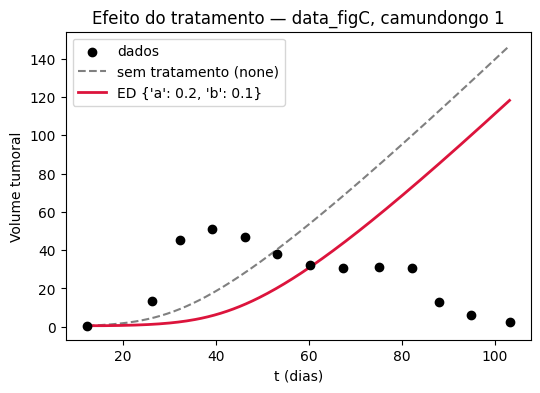

MSE deste chute = 2750.30   (quanto menor, melhor o ajuste)


In [8]:
# ----- Parâmetros de entrada -----
grupo_teste  = list(grouped_data.keys())[0]   # grupo (pasta)
mouse_idx    = 0                              # camundongo (0 = primeiro)
tmodel_teste = "ED"                           # função de tratamento
tp_teste     = {"a": 0.2, "b": 0.1}           # parâmetros do ED (a, b)
# ---------------------------------

df = grouped_data[grupo_teste]["datasets"][mouse_idx]
t_obs = df["t"].to_numpy(float); v_obs = df["V"].to_numpy(float)
T0 = float(v_obs[0])
t_grid = np.linspace(t_obs.min(), t_obs.max(), 200)

_, v_sem = simulate_treatment(t_grid, T0, GROWTH_PARAMS, {}, "none", TREATMENT_DAYS, DOSES)
_, v_com = simulate_treatment(t_grid, T0, GROWTH_PARAMS, tp_teste, tmodel_teste, TREATMENT_DAYS, DOSES)
_, v_pts = simulate_treatment(t_obs, T0, GROWTH_PARAMS, tp_teste, tmodel_teste, TREATMENT_DAYS, DOSES)
mse = float(np.mean((v_pts - v_obs) ** 2))

plt.figure(figsize=(6, 4))
plt.scatter(t_obs, v_obs, color="black", zorder=3, label="dados")
plt.plot(t_grid, v_sem, color="gray", ls="--", label="sem tratamento (none)")
plt.plot(t_grid, v_com, color="crimson", lw=2, label=f"{tmodel_teste} {tp_teste}")
plt.xlabel("t (dias)"); plt.ylabel("Volume tumoral")
plt.title(f"Efeito do tratamento — {grupo_teste}, camundongo {mouse_idx+1}")
plt.legend(); plt.show()
print(f"MSE deste chute = {mse:.2f}   (quanto menor, melhor o ajuste)")

## 7. Estimativas iniciais e limites dos parâmetros de tratamento

Para cada função de tratamento, `get_treatment_spec` define os parâmetros a
estimar, com estimativa inicial e limites. Os limites são valores genéricos de
partida; se algum parâmetro ficar "no limite" (ver diagnósticos) ou o ajuste for
ruim, convém ajustá-los — a célula 6.1 ajuda a encontrar faixas razoáveis.

`get_t0_bounds` é idêntica à do controle: define a faixa do volume inicial $T_0$
de cada camundongo.

In [9]:
def get_treatment_spec(model):
    '''Parâmetros, estimativa inicial, limites e conversor de cada função de tratamento.

    Versão de ensino: 'none' e 'ED'. Para adicionar funções, ver a seção 7.1.
    '''
    if model == "none":          # linha de base: nenhum parâmetro de tratamento
        return {"n": 0, "names": [], "x0": np.array([]), "bounds": [],
                "to_params": lambda x: {}}

    if model == "ED":            # decaimento exponencial: parâmetros a, b
        return {"n": 2, "names": ["a", "b"], "x0": np.array([0.2, 0.1]),
                "bounds": [(0.0, 3.0), (0.0, 5.0)],
                "to_params": lambda x: {"a": x[0], "b": x[1]}}

    # ----- PONTO DE EXTENSÃO: spec da nova função entra aqui -----
    # if model == "CD":
    #     return {"n": 2, "names": ["a", "b"], "x0": np.array([0.1, 0.1]),
    #             "bounds": [(0.0, 3.0), (0.0, 8.0)],
    #             "to_params": lambda x: {"a": x[0], "b": x[1]}}
    if model == "CD":
        return {"n": 2, "names": ["a", "b"], "x0": np.array([0.1, 0.1]),
                "bounds": [(0.0, 3.0), (0.0, 8.0)],
                "to_params": lambda x: {"a": x[0], "b": x[1]}}

    if model == "AccelED":
        return {"n": 2, "names": ["a", "b"], "x0": np.array([0.2, 0.1]),
                "bounds": [(0.0, 3.0), (0.0, 5.0)],
                "to_params": lambda x: {"a": x[0], "b": x[1]}}

    if model == "MM":
        return {"n": 2, "names": ["a", "b"], "x0": np.array([0.5, 0.5]),
                "bounds": [(0.0, 5.0), (0.0, 5.0)],
                "to_params": lambda x: {"a": x[0], "b": x[1]}}

    if model == "LS":
        return {"n": 2, "names": ["a", "b"], "x0": np.array([0.5, 0.01]),
                "bounds": [(0.0, 5.0), (0.0, 1.0)],
                "to_params": lambda x: {"a": x[0], "b": x[1]}}

    if model == "dePR":
        return {"n": 3, "names": ["d", "s", "lam"], "x0": np.array([0.5, 1.0, 1.0]),
                "bounds": [(0.0, 5.0), (1e-6, 50.0), (0.1, 5.0)],
                "to_params": lambda x: {"d": x[0], "s": x[1], "lam": x[2]}}

    raise ValueError(f"Função de tratamento desconhecida: {model}")


def get_t0_bounds(volume_arrays):
    guesses, bounds = [], []
    for v in volume_arrays:
        v0 = float(v[0])
        lo = max(1e-6, T0_BOUND_FRACTION_LOW * v0)
        hi = max(v0 * (1.0 + T0_BOUND_BUFFER), T0_BOUND_FRACTION_HIGH * v0)
        guesses.append(v0); bounds.append((lo, hi))
    return np.array(guesses, dtype=float), bounds

### 7.1 Receita para construir as outras funções de tratamento

Cada nova função de tratamento exige **três edições**, sempre nos mesmos lugares:

1. **Fórmula** — em `treatment_effect` (seção 5), acrescentar um ramo
   `elif model == "NOME":` calculando a contribuição da função para `eff`.
2. **Parâmetros** — em `get_treatment_spec` (seção 7), acrescentar a entrada com
   `n` (número de parâmetros), `names`, `x0` (estimativa inicial), `bounds`
   (limites) e `to_params` (converte o vetor em dicionário).
3. **Registro** — incluir `"NOME"` na lista `TREATMENT_MODELS` (seção 2).

Fórmulas prontas para colar como novos ramos (com $\Delta = t-\tau$, dose $d$,
dose acumulada `cum`, tumor $T$):

| Nome | Linha em `treatment_effect` | Parâmetros (spec) |
|---|---|---|
| `CD` | `eff += tp["a"] * cum * math.exp(-tp["b"] * dt)` | `a, b` |
| `AccelED` | `eff += tp["a"] * d * math.exp(-tp["b"] * dt * dt)` | `a, b` |
| `MM` | `eff += (tp["a"] * d) / (1.0 + tp["b"] * d)` | `a, b` |
| `LS` | `eff += (tp["a"] * d) / (1.0 + tp["b"] * T)` | `a, b` |
| `dePR` | `eff += tp["d"] * d**tp["lam"] / (tp["s"]*T**tp["lam"] + d**tp["lam"])` | `d, s, lam` |

A célula abaixo é um **modelo comentado** (não executa) mostrando exatamente como
ficariam as edições 1 e 2 para a função `CD`. Para ativá-la de fato, copie esses
trechos para dentro de `treatment_effect` e `get_treatment_spec` e adicione `"CD"`
em `TREATMENT_MODELS`.

In [10]:
# === EXEMPLO COMENTADO: como adicionar a função "CD" (dose cumulativa) ===
#
# 1) Em treatment_effect, dentro do laço 'for d, tau ...', após o ramo do ED:
#
#        elif model == "CD":
#            eff += tp["a"] * cum * math.exp(-tp["b"] * dt)
#
# 2) Em get_treatment_spec, antes do 'raise':
#
#        if model == "CD":
#            return {"n": 2, "names": ["a", "b"], "x0": np.array([0.1, 0.1]),
#                    "bounds": [(0.0, 3.0), (0.0, 8.0)],
#                    "to_params": lambda x: {"a": x[0], "b": x[1]}}
#
# 3) Na seção 2:  TREATMENT_MODELS = ["none", "ED", "CD"]
#
# Nada a executar aqui: esta célula serve apenas de referência.
print("Receita carregada (célula de referência, sem efeito).")

Receita carregada (célula de referência, sem efeito).


## 8. Estimação dos parâmetros (calibração)

O esquema é o mesmo do controle. O vetor de incógnitas agora é

$$\theta = [\underbrace{\text{parâmetros do tratamento}}_{\text{comuns ao grupo}},\; T_{0,1}, \dots, T_{0,n}]$$

O crescimento entra como contexto fixo (`GROWTH_PARAMS`). A função objetivo simula
cada camundongo e soma os erros quadráticos; o otimizador `L-BFGS-B`, com
múltiplos pontos de partida (*multistart*), minimiza esse erro. As funções
auxiliares de otimização são idênticas às do notebook de crescimento.

In [11]:
def clip_to_bounds(x, bounds):
    x = np.asarray(x, dtype=float).copy()
    for i, (lo, hi) in enumerate(bounds):
        x[i] = np.clip(x[i], lo, hi)
    return x


def sample_param_within_bounds(rng, lo, hi):
    if lo <= 0:
        return rng.uniform(lo, hi)
    if hi / max(lo, 1e-12) >= 50:
        return float(np.exp(rng.uniform(np.log(lo), np.log(hi))))
    return rng.uniform(lo, hi)


def generate_starting_points(base_x0, bounds, n_starts, rng):
    starts = [clip_to_bounds(base_x0, bounds)]
    base = np.asarray(base_x0, dtype=float)
    for m in [0.5, 0.8, 1.2, 1.5]:
        if len(starts) >= n_starts:
            break
        starts.append(clip_to_bounds(base * m, bounds))
    while len(starts) < n_starts:
        trial = np.array([sample_param_within_bounds(rng, lo, hi) for lo, hi in bounds])
        starts.append(clip_to_bounds(trial, bounds))
    seen, deduped = set(), []
    for x in starts:
        key = tuple(np.round(x, 10))
        if key not in seen:
            seen.add(key); deduped.append(x)
    return deduped


def objective_factory(model, t_list, v_list, n_treat, to_params):
    big_penalty = 1e18
    def objective(theta):
        treat = theta[:n_treat]; T0_vec = theta[n_treat:]
        try:
            tp = to_params(treat)
            sqerr_total, n_total = 0.0, 0
            for t_obs, v_obs, T0_i in zip(t_list, v_list, T0_vec):
                if T0_i <= 0 or not np.isfinite(T0_i):
                    return big_penalty
                _, v_hat = simulate_treatment(t_obs, T0_i, GROWTH_PARAMS, tp, model,
                                              TREATMENT_DAYS, DOSES)
                if np.any(~np.isfinite(v_hat)):
                    return big_penalty
                sqerr_total += float(np.sum((v_hat - v_obs) ** 2)); n_total += len(v_obs)
            return sqerr_total / max(n_total, 1)
        except Exception:
            return big_penalty
    return objective


def multistart_optimize(objective, x0, bounds, rng, n_starts):
    starts = generate_starting_points(x0, bounds, n_starts, rng)
    best_res, successful = None, 0
    for start in starts:
        try:
            res = minimize(objective, start, method="L-BFGS-B", bounds=bounds,
                           options={"maxiter": OPT_MAXITER, "maxfun": 5000, "maxls": 30})
        except Exception:
            continue
        if np.isfinite(res.fun):
            successful += int(bool(res.success))
            if best_res is None or res.fun < best_res.fun:
                best_res = res
    if best_res is None:
        raise RuntimeError("Todas as tentativas de otimização falharam.")
    return best_res, len(starts), successful

## 9. Métricas de comparação

Idênticas às do controle: critérios de informação (BIC principal, AIC, AICc) que
penalizam complexidade, e métricas de ajuste (RMSE, MAE, WAPE/sMAPE, PCC, CCC, ICC).
Aqui $k$ conta os parâmetros do tratamento mais os $T_0$ (o crescimento é fixo e
não entra na contagem).

In [12]:
def aic_from_ll(ll, k):            return 2 * k - 2 * ll
def bic_from_ll(ll, k, n):         return k * np.log(n) - 2 * ll
def aicc_from_aic(aic, k, n):
    d = n - k - 1
    return aic + (2 * k * (k + 1)) / d if d > 0 else np.nan

def loglik_gaussian(y, yhat):
    resid = np.asarray(y, float) - np.asarray(yhat, float)
    var = max(np.var(resid, ddof=1) if len(resid) > 1 else np.var(resid), 1e-12)
    return -0.5 * np.sum(resid ** 2 / var + np.log(2 * np.pi) + np.log(var))

def rmse(y, yhat): return float(np.sqrt(np.mean((np.asarray(y,float)-np.asarray(yhat,float))**2)))
def mae(y, yhat):  return float(np.mean(np.abs(np.asarray(y,float)-np.asarray(yhat,float))))

def wape(y, yhat):
    y = np.asarray(y,float); yhat = np.asarray(yhat,float); d = np.sum(np.abs(y))
    return float(100*np.sum(np.abs(y-yhat))/d) if d > 0 else np.nan

def smape(y, yhat):
    y = np.asarray(y,float); yhat = np.asarray(yhat,float)
    d = np.where(np.abs(y)+np.abs(yhat) <= 1e-12, 1e-12, np.abs(y)+np.abs(yhat))
    return float(100*np.mean(2*np.abs(y-yhat)/d))

def pcc(y, yhat):
    y = np.asarray(y,float); yhat = np.asarray(yhat,float)
    return np.corrcoef(y, yhat)[0, 1] if len(y) >= 2 else np.nan

def ccc(y, yhat):
    y = np.asarray(y,float); yhat = np.asarray(yhat,float)
    if len(y) < 2: return np.nan
    cov = np.cov(y, yhat, ddof=1)[0, 1]
    d = np.var(y,ddof=1) + np.var(yhat,ddof=1) + (np.mean(y)-np.mean(yhat))**2
    return (2*cov)/d if d > 0 else np.nan

def icc_a1(y, yhat):
    y = np.asarray(y,float); yhat = np.asarray(yhat,float)
    if len(y) < 2: return np.nan
    X = np.column_stack([y, yhat]); n, k = X.shape
    mr = np.mean(X,1,keepdims=True); mc = np.mean(X,0,keepdims=True); gm = np.mean(X)
    ss_r = k*np.sum((mr-gm)**2); ss_c = n*np.sum((mc-gm)**2); ss_e = np.sum((X-mr-mc+gm)**2)
    df_r, df_c, df_e = n-1, k-1, (n-1)*(k-1)
    if df_r <= 0 or df_e <= 0: return np.nan
    ms_r = ss_r/df_r; ms_c = ss_c/df_c if df_c > 0 else 0.0; ms_e = ss_e/df_e
    den = ms_r + (k-1)*ms_e + (k*(ms_c-ms_e)/n)
    return (ms_r-ms_e)/den if not np.isclose(den, 0) else np.nan

def metrics_from_predictions(y, yhat, k_total):
    ll = loglik_gaussian(y, yhat); aic = aic_from_ll(ll, k_total)
    return {"ll": ll, "aic": aic, "aicc": aicc_from_aic(aic, k_total, len(y)),
            "bic": bic_from_ll(ll, k_total, len(y)),
            "mse": float(np.mean((np.asarray(y)-np.asarray(yhat))**2)),
            "rmse": rmse(y,yhat), "mae": mae(y,yhat), "wape": wape(y,yhat),
            "smape": smape(y,yhat), "pcc": pcc(y,yhat), "ccc": ccc(y,yhat),
            "icc": icc_a1(y,yhat), "k_total": k_total}

## 10. Ajuste de uma função de tratamento a um grupo

`fit_treatment_model` executa o ciclo completo para uma função de tratamento:
monta o vetor $\theta$, otimiza (multistart, com o crescimento fixo), simula o
ajuste final de cada camundongo e calcula as métricas. `build_diagnostics`
sinaliza parâmetros próximos dos limites. Como no controle, aceita `x0_override`
e `n_starts` para reaproveitamento na etapa de predição.

In [13]:
def is_near_bound(value, bound, rel_tol=BOUNDARY_TOL_REL):
    lo, hi = bound
    if not np.isfinite(value) or hi <= lo: return False
    w = hi - lo
    return (value - lo) <= rel_tol*w or (hi - value) <= rel_tol*w


def build_diagnostics(tp, T0_list, treat_bounds, t0_bounds):
    notes = []
    for (name, value), bound in zip(tp.items(), treat_bounds):
        if is_near_bound(float(value), bound):
            notes.append(f"{name} no limite [{bound[0]:.4g}, {bound[1]:.4g}]")
    for idx, (val, bound) in enumerate(zip(T0_list, t0_bounds), start=1):
        if is_near_bound(float(val), bound):
            notes.append(f"T0_{idx} no limite [{bound[0]:.4g}, {bound[1]:.4g}]")
    return notes if notes else ["sem problemas óbvios"]


def fit_treatment_model(model, datasets, rng, x0_override=None, n_starts=None):
    if n_starts is None:
        n_starts = MULTISTART_N_STARTS
    t_list = [df["t"].to_numpy(float) for df in datasets]
    v_list = [df["V"].to_numpy(float) for df in datasets]
    n_mice = len(datasets)

    spec = get_treatment_spec(model)
    n_treat = spec["n"]
    T0_guess, T0_bounds = get_t0_bounds(v_list)
    bounds = list(spec["bounds"]) + T0_bounds
    x0 = np.concatenate([spec["x0"], T0_guess]) if x0_override is None \
         else clip_to_bounds(x0_override, bounds)

    objective = objective_factory(model, t_list, v_list, n_treat, spec["to_params"])
    result, n_used, n_ok = multistart_optimize(objective, x0, bounds, rng, n_starts)
    if not np.isfinite(result.fun):
        raise RuntimeError(f"Otimização falhou para o tratamento '{model}'.")

    theta_hat = clip_to_bounds(result.x, bounds)
    tp = spec["to_params"](theta_hat[:n_treat])
    T0_hat = theta_hat[n_treat:]

    fits, v_obs_all, v_fit_all = [], [], []
    for i, (t_obs, v_obs, T0_i) in enumerate(zip(t_list, v_list, T0_hat), start=1):
        t_fit, v_fit = simulate_treatment(t_obs, T0_i, GROWTH_PARAMS, tp, model,
                                          TREATMENT_DAYS, DOSES)
        fits.append({"mouse": i, "t_obs": t_obs, "V_obs": v_obs,
                     "t_fit": t_fit, "V_fit": v_fit, "T0": T0_i})
        v_obs_all.append(v_obs); v_fit_all.append(v_fit)

    k_total = n_treat + (n_mice if COUNT_T0_IN_AIC_BIC else 0)
    metrics = metrics_from_predictions(np.concatenate(v_obs_all),
                                       np.concatenate(v_fit_all), k_total)
    diag = build_diagnostics(tp, T0_hat, list(spec["bounds"]), T0_bounds)
    return {"model": model, "params_est": tp, "T0_list": T0_hat, "theta_hat": theta_hat,
            "fits_by_mouse": fits, "metrics": metrics, "diagnostics": diag,
            "optimization": {"objective": float(result.fun), "success": bool(result.success),
                             "n_starts_used": n_used, "n_successful_starts": n_ok}}


def calibrate_treatment_model(model, datasets, seed):
    fit = fit_treatment_model(model, datasets, np.random.default_rng(seed))
    fit["validation"] = None
    return fit

## 11. Avaliação da predição do último ponto

Mesmo procedimento do controle: remove-se o último ponto de cada curva, calibra-se
o tratamento apenas com os pontos restantes e prevê-se o ponto removido. Por
eficiência, reaproveitam-se os parâmetros já obtidos como estimativa inicial, e a
validação é feita apenas para os `VALIDATION_TOP_K` melhores modelos.

In [14]:
def build_validation_datasets(datasets):
    train, holdout = [], []
    for i, df in enumerate(datasets, start=1):
        if len(df) < 4:
            return None, None
        train.append(df.iloc[:-1].reset_index(drop=True))
        last = df.iloc[-1]
        holdout.append({"mouse": i, "t": float(last["t"]), "V": float(last["V"])})
    return train, holdout


def evaluate_last_point_validation(model, datasets, seed, warm_theta=None):
    train, holdout = build_validation_datasets(datasets)
    if train is None:
        return None
    n_starts = 2 if warm_theta is not None else MULTISTART_N_STARTS
    fit = fit_treatment_model(model, train, np.random.default_rng(seed),
                              x0_override=warm_theta, n_starts=n_starts)
    y_true, y_pred, per_mouse = [], [], []
    for mf, h in zip(fit["fits_by_mouse"], holdout):
        t_eval = np.append(np.asarray(mf["t_fit"], float), h["t"])
        _, pred = simulate_treatment(t_eval, float(mf["T0"]), GROWTH_PARAMS,
                                     fit["params_est"], model, TREATMENT_DAYS, DOSES)
        v_pred = float(pred[-1])
        y_true.append(h["V"]); y_pred.append(v_pred)
        per_mouse.append({"mouse": h["mouse"], "t_holdout": h["t"],
                          "V_true": h["V"], "V_pred": v_pred,
                          "abs_error": abs(v_pred - h["V"])})
    return {"metrics": {"rmse": rmse(y_true,y_pred), "mae": mae(y_true,y_pred),
                        "wape": wape(y_true,y_pred), "smape": smape(y_true,y_pred),
                        "pcc": pcc(y_true,y_pred), "ccc": ccc(y_true,y_pred),
                        "n_holdout": len(y_true)},
            "per_mouse": per_mouse}


def attach_validation_to_top_models(results, datasets, base_seed, top_k=None):
    if top_k is None:
        top_k = VALIDATION_TOP_K
    if not USE_LAST_POINT_VALIDATION or not top_k or top_k <= 0:
        return results
    ranked = sorted(results, key=lambda x: x["metrics"]["bic"])
    selected = {r["model"] for r in ranked[:min(top_k, len(ranked))]}
    for idx, res in enumerate(results):
        if res["model"] not in selected:
            continue
        try:
            res["validation"] = evaluate_last_point_validation(
                res["model"], datasets, base_seed + 10_000 + idx,
                warm_theta=res.get("theta_hat"))
        except Exception as exc:
            res["validation"] = {"error": str(exc)}
    return results

## 12. Tabela-resumo, relatório e gráfico

Mesma apresentação do controle, agora comparando funções de tratamento. A figura
mostra, por camundongo, os dados e a curva de cada função; a de menor BIC é
destacada.

In [15]:
def build_summary_table(results):
    rows = []
    for res in results:
        m = res["metrics"]; val = res.get("validation")
        vm = val.get("metrics") if isinstance(val, dict) and "metrics" in val else None
        rows.append({"model": res["model"], "BIC": m["bic"], "AIC": m["aic"],
                     "AICc": m["aicc"], "LogLik": m["ll"], "RMSE": m["rmse"],
                     "MAE": m["mae"], "WAPE (%)": m["wape"], "sMAPE (%)": m["smape"],
                     "PCC": m["pcc"], "CCC": m["ccc"], "ICC": m["icc"],
                     "CV_RMSE": np.nan if vm is None else vm["rmse"],
                     "CV_MAE":  np.nan if vm is None else vm["mae"],
                     "diagnostics": " | ".join(res["diagnostics"])})
    df = pd.DataFrame(rows).sort_values(MODEL_SELECTION_METRIC).reset_index(drop=True)
    df["ΔBIC"] = df["BIC"] - df["BIC"].min()
    df["ΔAICc"] = df["AICc"] - df["AICc"].min(skipna=True)
    return df


def sanitize_filename(name): return re.sub(r"[^A-Za-z0-9_.-]+", "_", str(name))
def ensure_output_dir(base):
    out = Path(base) / OUTPUT_DIRNAME; out.mkdir(parents=True, exist_ok=True); return out
def get_layout(n, max_cols=3):
    if n <= 0: return 1, 1
    c = min(max_cols, n); return math.ceil(n / c), c


def format_group_report(group_name, filepaths, datasets, results, summary_df):
    L = ["="*90, f"RESULTADOS DO GRUPO TRATADO: {group_name}", "="*90, "",
         f"Crescimento fixo: {GROWTH_MODEL} {GROWTH_PARAMS}",
         f"Esquema: dias={TREATMENT_DAYS} doses={DOSES}", "", "ARQUIVOS"]
    for i, (fp, df) in enumerate(zip(filepaths, datasets), start=1):
        L.append(f"  Camundongo {i}: {Path(fp).name} | n={len(df)} | "
                 f"t∈[{df['t'].min():.2f},{df['t'].max():.2f}] | "
                 f"V∈[{df['V'].min():.4g},{df['V'].max():.4g}]")
    L += ["", "COMPARAÇÃO DAS FUNÇÕES DE TRATAMENTO (ordenado por BIC)",
          summary_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"), ""]
    L.append(f"MELHOR FUNÇÃO POR {MODEL_SELECTION_METRIC}: {summary_df.iloc[0]['model']}")
    L += ["", "PARÂMETROS E DIAGNÓSTICOS"]
    for res in sorted(results, key=lambda x: x["metrics"]["bic"]):
        L.append(f"\n[{res['model']}]  objetivo={res['optimization']['objective']:.6g}")
        if res["params_est"]:
            for name, value in res["params_est"].items():
                L.append(f"  {name:>5s} = {value:.6g}")
        else:
            L.append("  (sem parâmetros de tratamento)")
        for i, T0 in enumerate(res["T0_list"], start=1):
            L.append(f"  T0_camundongo_{i} = {T0:.6g}")
        for note in res["diagnostics"]:
            L.append(f"    - {note}")
        val = res.get("validation")
        if isinstance(val, dict) and "metrics" in val:
            vm = val["metrics"]
            L.append(f"  PREDIÇÃO último ponto: RMSE={vm['rmse']:.4g} "
                     f"MAE={vm['mae']:.4g} WAPE={vm['wape']:.2f}% CCC={vm['ccc']:.3f}")
            for r in val["per_mouse"]:
                L.append(f"    Camundongo {r['mouse']}: t={r['t_holdout']:.1f} "
                         f"real={r['V_true']:.4g} previsto={r['V_pred']:.4g} "
                         f"erro={r['abs_error']:.4g}")
    return "\n".join(L)


def build_parameter_table(results):
    rows = []
    for res in results:
        base = {"model": res["model"]}
        base.update(res["params_est"])
        for i, v in enumerate(res["T0_list"], start=1):
            base[f"T0_camundongo_{i}"] = v
        rows.append(base)
    return pd.DataFrame(rows)


def write_reports(output_dir, group_name, filepaths, datasets, results, summary_df):
    sg = sanitize_filename(group_name)
    text = format_group_report(group_name, filepaths, datasets, results, summary_df)
    (output_dir / f"report_tratamento_{sg}.txt").write_text(text, encoding="utf-8")
    summary_df.to_csv(output_dir / f"summary_tratamento_{sg}.csv", index=False)
    build_parameter_table(results).to_csv(output_dir / f"parameters_tratamento_{sg}.csv", index=False)
    return text


def plot_fits(datasets, results, group_name, output_name):
    rs = sorted(results, key=lambda x: x["metrics"]["bic"])
    best = rs[0]["model"]; n = len(datasets)
    n_rows, n_cols = get_layout(n, 3)
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(max(4.8*n_cols,6.0), max(3.8*n_rows+1.2,4.8)),
                             sharey=True, squeeze=False)
    axes = axes.ravel()
    legend = {}
    for j, ax in enumerate(axes):
        if j >= n:
            ax.axis("off"); continue
        df = datasets[j]
        ax.scatter(df["t"], df["V"], color="black", s=35, zorder=3, label="Dados")
        for res in rs:
            mdl = res["model"]; fit = res["fits_by_mouse"][j]
            line, = ax.plot(fit["t_fit"], fit["V_fit"],
                            lw=2.8 if mdl==best else 1.6,
                            alpha=1.0 if mdl==best else 0.7, label=mdl)
            legend.setdefault(mdl, line)
        ax.set_title(f"Camundongo {j+1}"); ax.set_xlabel("t (dias)")
        ax.grid(True, ls="--", alpha=0.35)
    axes[0].set_ylabel("Volume tumoral (mm³)")
    fig.suptitle(f"Tratamento — {group_name} | crescimento {GROWTH_MODEL} | "
                 f"melhor: {best} | BIC={rs[0]['metrics']['bic']:.2f}", y=0.995)
    fig.legend(list(legend.values()), list(legend.keys()), loc="upper center",
               ncol=min(7, len(legend)), frameon=True, bbox_to_anchor=(0.5, 0.955))
    plt.tight_layout(rect=[0, 0, 1, 0.90])
    plt.savefig(output_name, dpi=300, bbox_inches="tight")
    plt.show(); plt.close(fig)

## 13. Execução

Executa o procedimento para os grupos definidos em `GROUPS_TO_RUN`: calibra cada
função de tratamento sobre o crescimento fixo, valida a predição das melhores,
imprime o relatório, grava os arquivos e exibe a figura. Os resultados ficam em
`calibration_outputs_tratamento/`.

Saída em: C:\Users\nicol\OneDrive\Área de Trabalho\github parte_dos_dados_notebooks_calibracao_nicolly\calibration_outputs_tratamento



Calibrando tratamento (data_figC): 100%|██████████| 7/7 [00:28<00:00,  4.07s/modelo]
c:\Users\nicol\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\nicol\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
c:\Users\nicol\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\nicol\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
c:\Users\nicol\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c

RESULTADOS DO GRUPO TRATADO: data_figC

Crescimento fixo: linear {'r': 2.49815, 'f': 14.2442}
Esquema: dias=[12.0] doses=[1.0]

ARQUIVOS
  Camundongo 1: data_frosberg19_fig3C_hIL2_NOG_CART_2.csv | n=13 | t∈[12.29,103.17] | V∈[0.5089,50.89]
  Camundongo 2: data_frosberg19_fig3C_hIL2_NOG_CART_4.csv | n=13 | t∈[12.29,102.98] | V∈[0.5089,33.08]

COMPARAÇÃO DAS FUNÇÕES DE TRATAMENTO (ordenado por BIC)
  model      BIC      AIC     AICc    LogLik    RMSE     MAE  WAPE (%)  sMAPE (%)     PCC     CCC     ICC  CV_RMSE  CV_MAE                                                                                                                               diagnostics    ΔBIC   ΔAICc
     LS 235.2014 230.1690 232.0738 -111.0845 17.3379 13.7258   67.0414    78.6001 -0.1195 -0.0827 -0.0860  24.1090 24.1090                               a no limite [0, 5] | b no limite [0, 1] | T0_1 no limite [0.05089, 2.036] | T0_2 no limite [0.05089, 2.036]  0.0000  0.0000
     MM 235.2014 230.1690 232.0738 -111.0845 1

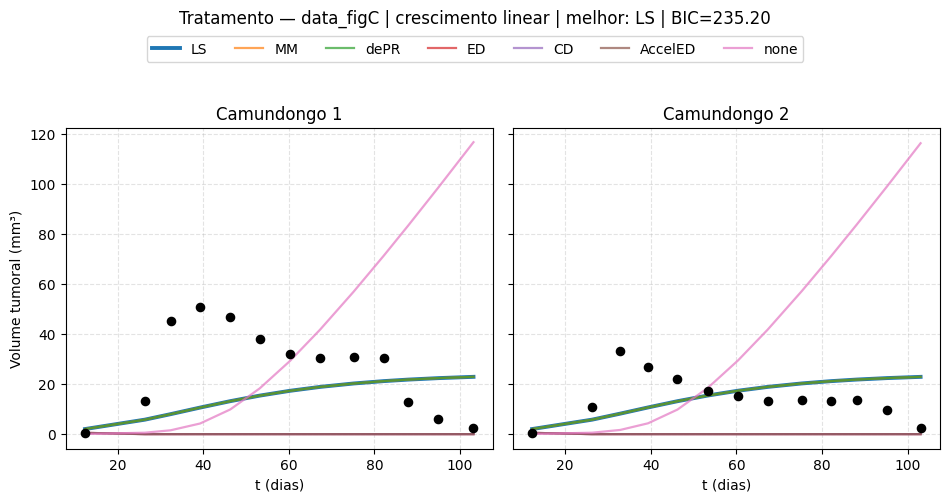


Arquivos salvos para o grupo 'data_figC'.

Concluído.


In [16]:
output_dir = ensure_output_dir(data_root)
print(f"Saída em: {output_dir}\n")
all_results = {}

if GROUPS_TO_RUN is None:
    items = list(grouped_data.items())
else:
    items = [(g, grouped_data[g]) for g in GROUPS_TO_RUN if g in grouped_data]

for gi, (group_name, gd) in enumerate(items):
    filepaths, datasets = gd["filepaths"], gd["datasets"]
    results = []
    for mi, model in enumerate(tqdm(TREATMENT_MODELS,
                                    desc=f"Calibrando tratamento ({group_name})", unit="modelo")):
        try:
            results.append(calibrate_treatment_model(model, datasets,
                                                     seed=RANDOM_SEED + 1000*gi + 100*mi))
        except Exception as e:
            print(f"[AVISO] {group_name} | {model} falhou: {e}")
    if not results:
        print(f"[AVISO] Nenhuma calibração para {group_name}"); continue

    results = attach_validation_to_top_models(results, datasets, RANDOM_SEED + 1000*gi)
    summary_df = build_summary_table(results)
    print(format_group_report(group_name, filepaths, datasets, results, summary_df))

    plot_fits(datasets, results, group_name,
              output_dir / f"calibracao_tratamento_{sanitize_filename(group_name)}.png")
    write_reports(output_dir, group_name, filepaths, datasets, results, summary_df)
    all_results[group_name] = {"results": results, "summary": summary_df}
    print(f"\nArquivos salvos para o grupo '{group_name}'.\n")

print("Concluído.")

## 14. Utilização com os dados tratados

1. Calibrar antes o crescimento no controle (notebook de crescimento) e anotar a
   lei vencedora e seus parâmetros (arquivo `parameters_*.csv`).
2. Preencher `GROWTH_MODEL` e `GROWTH_PARAMS` na seção 2 com esses valores.
3. Organizar os dados tratados na mesma convenção de pastas/arquivos e ajustar
   `FILE_GLOB` para o rótulo correspondente (por exemplo, `..._NOG_CART_*.csv`).
4. Definir o esquema de tratamento em `TREATMENT_DAYS` e `DOSES`.
5. Executar o notebook em ordem.

Notas:

- O modelo `none` (sem tratamento) serve de referência. Se ele vencer por BIC, os
  dados não sustentam um termo de tratamento com as funções testadas.
- Os limites dos parâmetros em `get_treatment_spec` são genéricos. Se um parâmetro
  ficar "no limite" (diagnósticos) ou o ajuste for ruim, ajustar os limites; a
  célula 6.1 ajuda a encontrar faixas razoáveis.
- O crescimento é mantido fixo para isolar o efeito do tratamento. Para também
  reestimar os parâmetros de crescimento, seria necessário incluí-los no vetor
  $\theta$ — extensão possível, fora do escopo desta versão.

## 15. Interpretação dos resultados

- Menor BIC indica a função de tratamento preferida; $\Delta\text{BIC} < 2$ indica
  equivalência prática (observar então AICc, RMSE e correlações).
- Diagnósticos: parâmetros no limite sugerem que os dados não restringem bem
  aquela função, ou que os limites precisam de ajuste.
- Comparar `RMSE` (ajuste) com `CV_RMSE` (predição): boa descrição do passado não
  garante boa previsão.
- Para comparar grupos (controle, CAR-T, CAR-T + IL-2), reunir as melhores funções
  e seus parâmetros de cada grupo; o crescimento, comum ao tumor, vem do controle.